# Операции над нечёткими множествами

Термы нечёткой переменной «цена обуви (базовая таблица):


In [ ]:
# price, mu_cheap, mu_average, mu_expensive, mu_very_expensive = mu_expensive ** 2
rows = [
    (1000, 1.00, 0,    0,    0   ), (2000, 0.80, 0.10, 0,    0   ), (3000, 0.40, 0.30, 0,    0   ),
    (4000, 0.20, 0.50, 0,    0   ), (5000, 0,    0.70, 0.10, 0.01), (6000, 0,    0.90, 0.20, 0.04),
    (7000, 0,    1.00, 0.30, 0.09), (8000, 0,    0.80, 0.35, 0.12), (9000, 0,    0.70, 0.40, 0.16),
    (10000,0,    0.60, 0.45, 0.20), (11000,0,    0.50, 0.50, 0.25), (12000,0,    0.30, 0.55, 0.30),
    (13000,0,    0.20, 0.60, 0.36), (14000,0,    0.10, 0.65, 0.42), (15000,0,    0,    0.70, 0.49),
    (16000,0,    0,    0.75, 0.56), (17000,0,    0,    0.80, 0.64), (18000,0,    0,    0.85, 0.72),
    (19000,0,    0,    0.90, 0.81), (20000,0,    0,    0.95, 0.90), (21000,0,    0,    0.98, 0.96),
    (22000,0,    0,    0.98, 0.96), (23000,0,    0,    0.98, 0.96), (24000,0,    0,    1.00, 1.00),
    (25000,0,    0,    1.00, 1.00),
]

def fuzzy_diff(mu_a, mu_b):
    # keep the value only where the two sets agree exactly, otherwise 0
    return mu_a if mu_a == mu_b else 0

cols = ["price", "cheap", "average", "expensive", "very_expensive",
        "cheap_or_average", "average_and_expensive", "average_diff_expensive",
        "compare_very_expensive_expensive"]

table_rows = []
for price, cheap, average, expensive, very_expensive in rows:
    cheap_or_average = max(cheap, average)
    average_and_expensive = min(average, expensive)
    average_diff_expensive = fuzzy_diff(average, expensive)
    compare_very_expensive_expensive = abs(very_expensive - expensive)
    table_rows.append([price, cheap, average, expensive, very_expensive,
                        cheap_or_average, average_and_expensive, average_diff_expensive,
                        compare_very_expensive_expensive])

from IPython.display import HTML, display
def fmt(v):
    return f"{v:.3f}" if isinstance(v, float) else str(v)
th = "".join(f"<th style='text-align:right;padding:4px 10px;border:1px solid #ccc;'>{c}</th>" for c in cols)
trs = "".join("<tr>" + "".join(f"<td style='text-align:right;padding:4px 10px;border:1px solid #ccc;'>{fmt(v)}</td>" for v in r) + "</tr>" for r in table_rows)
display(HTML(f"<table style='border-collapse:collapse;font-family:monospace;'><thead><tr>{th}</tr></thead><tbody>{trs}</tbody></table>"))


price,cheap,average,expensive,very_expensive,cheap_or_average,average_and_expensive,average_diff_expensive,compare_very_expensive_expensive
1000,1.000,0,0,0,1.000,0,0,0
2000,0.800,0.100,0,0,0.800,0,0,0
3000,0.400,0.300,0,0,0.400,0,0,0
4000,0.200,0.500,0,0,0.500,0,0,0
5000,0,0.700,0.100,0.010,0.700,0.100,0,0.090
6000,0,0.900,0.200,0.040,0.900,0.200,0,0.160
7000,0,1.000,0.300,0.090,1.000,0.300,0,0.210
8000,0,0.800,0.350,0.120,0.800,0.350,0,0.230
9000,0,0.700,0.400,0.160,0.700,0.400,0,0.240
10000,0,0.600,0.450,0.200,0.600,0.450,0,0.250


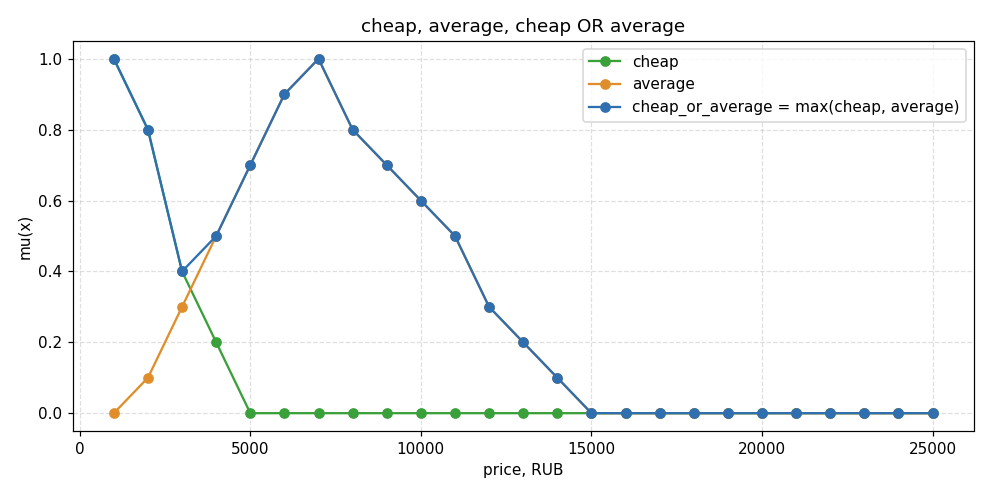

In [ ]:
import matplotlib.pyplot as plt

price = [r[0] for r in rows]
cheap = [r[1] for r in rows]
average = [r[2] for r in rows]
cheap_or_average = [max(c, a) for c, a in zip(cheap, average)]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(price, cheap, "o-", label="cheap", color="#3aa03a")
ax.plot(price, average, "o-", label="average", color="#e08e2b")
ax.plot(price, cheap_or_average, "o-", label="cheap_or_average = max(cheap, average)", color="#2f6fb0")
ax.set_xlabel("price, RUB")
ax.set_ylabel("mu(x)")
ax.set_title("cheap, average, cheap OR average")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()


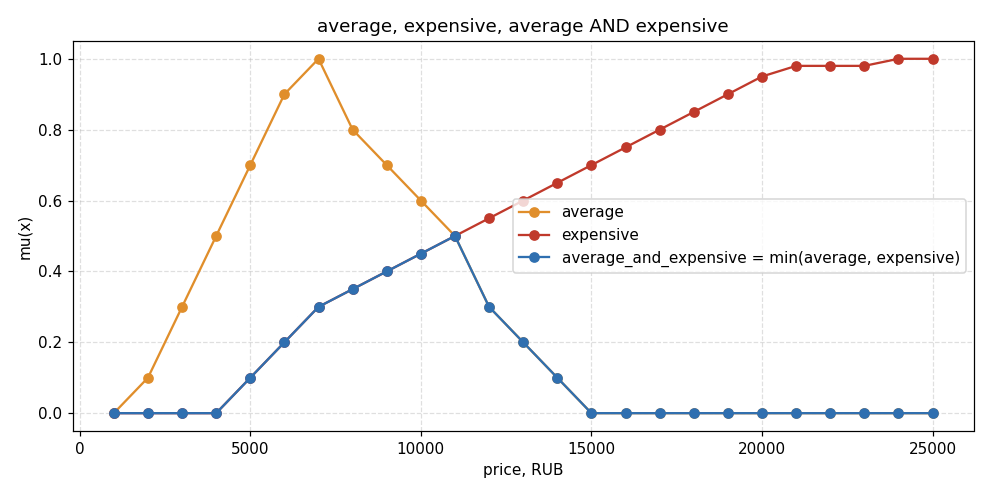

In [ ]:
import matplotlib.pyplot as plt

price = [r[0] for r in rows]
average = [r[2] for r in rows]
expensive = [r[3] for r in rows]
average_and_expensive = [min(a, e) for a, e in zip(average, expensive)]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(price, average, "o-", label="average", color="#e08e2b")
ax.plot(price, expensive, "o-", label="expensive", color="#c0392b")
ax.plot(price, average_and_expensive, "o-", label="average_and_expensive = min(average, expensive)", color="#2f6fb0")
ax.set_xlabel("price, RUB")
ax.set_ylabel("mu(x)")
ax.set_title("average, expensive, average AND expensive")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()


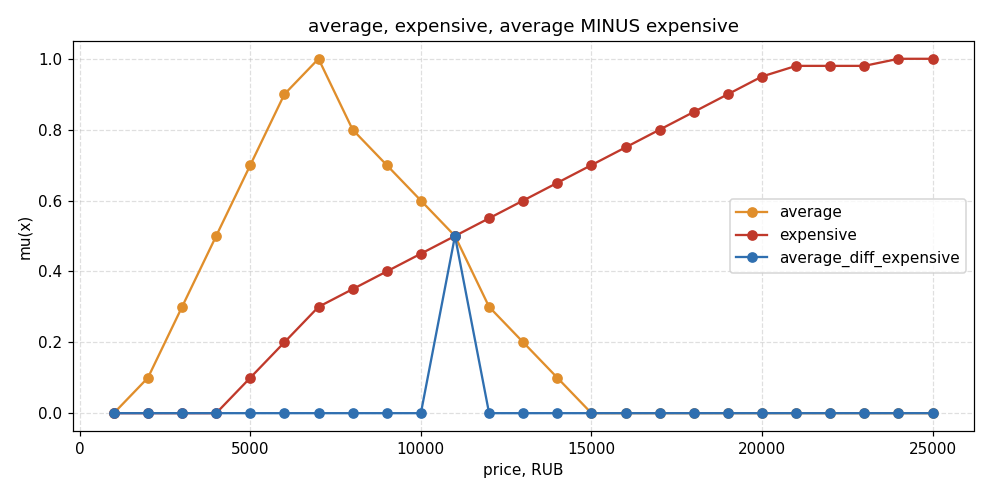

In [ ]:
import matplotlib.pyplot as plt

price = [r[0] for r in rows]
average = [r[2] for r in rows]
expensive = [r[3] for r in rows]
average_diff_expensive = [fuzzy_diff(a, e) for a, e in zip(average, expensive)]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(price, average, "o-", label="average", color="#e08e2b")
ax.plot(price, expensive, "o-", label="expensive", color="#c0392b")
ax.plot(price, average_diff_expensive, "o-", label="average_diff_expensive", color="#2f6fb0")
ax.set_xlabel("price, RUB")
ax.set_ylabel("mu(x)")
ax.set_title("average, expensive, average MINUS expensive")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()


In [ ]:
# degree of equality E(A=B) = 1 - max|mu_A(x) - mu_B(x)| over x where mu_A(x) != mu_B(x)
compare_diffs = [abs(r[4] - r[3]) for r in rows]
comparison_very_expensive_expensive = 1 - max(compare_diffs)
print("E(very_expensive = expensive) =", round(comparison_very_expensive_expensive, 3))


E(very_expensive = expensive) = 0.75
